# Métodos Computacionales

## Unidad 2:

### Otras librerias

1. Sympy
2. Scipy

# Sympy

## Como usar sympy

Sympy es la librería para cálculos simbólicos en python, también tiene definidas las funciones, `sin(x)`, `cos(x)`, `log(x)`, `exp(x)`, `pi`, etc, pero de manera simbólica, se pueden importar usando,
```python
    from sympy import *
```
o también,
```python
    import sympy as sp
```
Aquí utilizamos la primera forma, para evitar confusiones con las funciones numéricas de numpy estas se importarán como,
```python
    import numpy as np
```
así, en numpy las funciones serán: `np.sin(x)`, `np.log(x)`, `np.exp(x)`, etc.
  
IMPORTANTE: No usar `%pylab` después de importar sympy como `"from sympy import *"`, puesto que este comando usa `"from numpy import *"` y numpy sobrepone sus funciones sobre las de sympy, lo correcto es,
```python
    %pylab
    from sympy import *
```
así por ejemplo `exp(x)`, `pi`, etc son sympy (cálculos simbólicos) y `np.exp(x)`, `np.pi`, son numpy (cálculos con arrays numpy).

Si se usa por ejemplo, `np.log(x)` en manera simbolica o `log(x)` de manera númerica, dará error.

Para más, ver [Tutorial sympy](https://www.southampton.ac.uk/~fangohr/teaching/python/book/html/12-symbolic-computation.html).

## Derivadas analíticas usando python y su librería sympy

Para calcular derivada se usa el comando `sympy.diff()`, en cualquiera de las siguientes dos maneras,
```python
    f.diff(x,n) # derivada de orden n
    diff(f,x,n)
```    
pero primero se define la la variable $x$ mediante el comando `sp.Symbol()` o `sp.symbols()`. Ejemplo, consideremos la función,
$$f(t)=\frac{10 \log{\left (t^{2} + t + 1 \right )}}{10 t^{3} - 20 t^{2} + t - 2}$$

In [ ]:
from sympy import *
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Ejemplo 1)
t         = Symbol ('t')       # definir un solo símbolo,
# x,y,z,t = symbols('x,y,z,t') # definir varios símbolos,

y = 10*log(t**2+t+1)/(10*t**3-20*t**2+t-2) # crear una función simbólica
# print(y), print(display(y))  # comparar print() y display()
y # imprimir la función (de click derecho sobre la función, escoja Show Math As y escoja)

10*log(t**2 + t + 1)/(10*t**3 - 20*t**2 + t - 2)

In [ ]:
# 1) Derivada analítica de y en t
dy = y.diff(t)
#dy = (10*log(t**2+t+1)/(10*t**3 - 20*t**2 +t-2).diff(t) # otra alternativa

# 2) Note otra forma de tener la derivada analítica:
diff(y,t)
#diff(10*log(t**2+t+1)/(10*t**3 - 20*t**2 +t-2),t)
# la derivada analítica es más complicada de calcular:

10*(2*t + 1)/((t**2 + t + 1)*(10*t**3 - 20*t**2 + t - 2)) + 10*(-30*t**2 + 40*t - 1)*log(t**2 + t + 1)/(10*t**3 - 20*t**2 + t - 2)**2

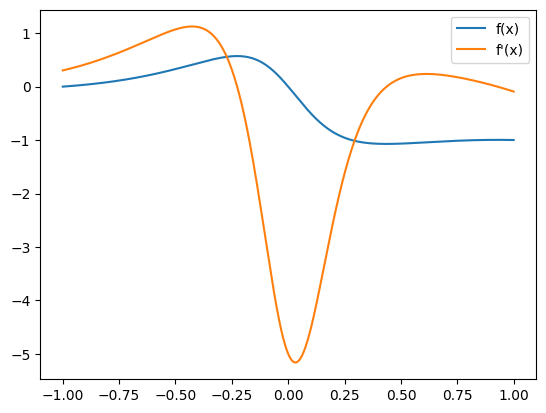

In [ ]:
# Se usa lambdify para crear una forma numérica de las funciones:
f  = lambdify(t, y , 'numpy') # crea función f(t) y que puede ser usada en numpy
df = lambdify(t, dy, 'numpy') # crea función numérica de la derivada

x = np.linspace(-1,1,1000)

plt.plot(x, f(x),label="f(x)")
plt.plot(x,df(x),label="f'(x)")

plt.legend()
plt.show()

# Otras funciones

In [ ]:
x = Symbol('x')
y = Symbol('y')
expand((x+y)**3) # expandir


x**3 + 3*x**2*y + 3*x*y**2 + y**3

In [ ]:
expand(cos(x+y), trig=True)

-sin(x)*sin(y) + cos(x)*cos(y)

In [ ]:
simplify((x+x*y)/x) # simplificar

y + 1

In [ ]:
#diff(sin(2*x), x, 1) # derivada de orden superior
#diff(sin(2*x), x, 2)
diff(sin(2*x), x, 3)

-8*cos(2*x)

In [ ]:
series(cos(x), x) # series

1 - x**2/2 + x**4/24 + O(x**6)

# Encontrar raices

In [ ]:
solve(x**4 - 1, x)

[-1, 1, -I, I]

# Scipy

In [ ]:
x=np.array([0.,  0.36363636,  0.72727273,  1.09090909,  1.45454545, 1.81818182,
          2.18181818,  2.54545455,  2.90909091,  3.27272727,  3.63636364,  4.])

y=np.array([-0.65364362,  -0.61966189,  -0.51077021,  -0.31047698,  -0.00715476,
           0.37976236,   0.76715099,   0.99239518,   0.85886263,   0.27994201,
          -0.52586509,  -0.99582185])


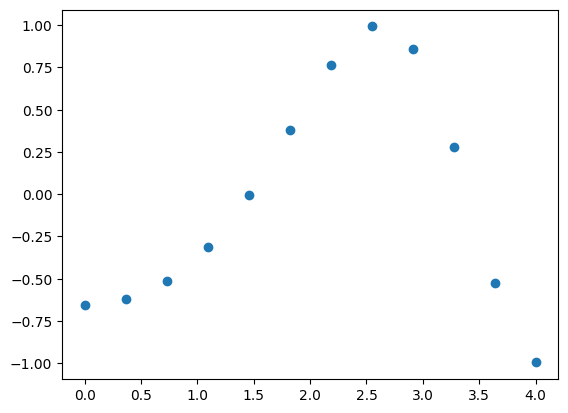

In [ ]:
plt.plot(x, y,'o')
plt.show()

In [ ]:
from scipy import*
f1 = interpolate.interp1d(x, y,kind = 'linear')

f2 = interpolate.interp1d(x, y, kind = 'cubic')

In [ ]:
f1

In [ ]:
f1(2)

array(0.57345667)

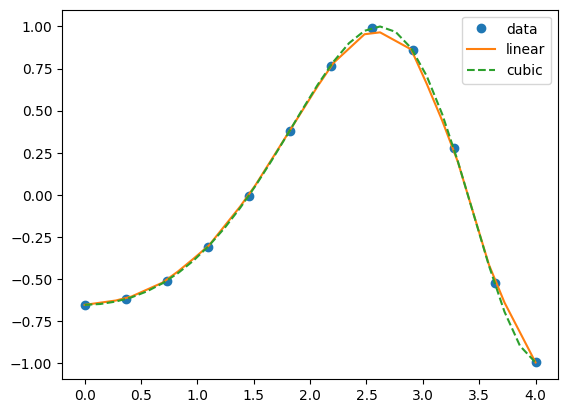

In [ ]:
xnew = np.linspace(0, 4,30)
plt.plot(x, y, 'o', xnew, f1(xnew), '-', xnew, f2(xnew), '--')

plt.legend(['data', 'linear', 'cubic','nearest'], loc = 'best')

plt.show()

Rutina de interpolación alternativa,
```python
scipy.interpolate.interp1d(x, y, kind=tipo)
```
Tiene `kind` las siguientes opciones:
* *nearest*: "snaps" más cercanos al punto de datos más cercano.
*    *zero*: es una spline de orden cero, su valor en cualquier momento es el último valor bruto visto.
*    *linear*: hace interpolación lineal.
*    *slinear*: usa una spline de primer orden. *linar* y *slinear* código diferente y pueden producir resultados similares aunque sutilmente diferentes.
*    *quadratic*: interpolación de segundo orden.
*    *cubic*: interpolación de tercer orden (splines cúbicos).

In [ ]:
from scipy.interpolate import lagrange
x = np.array([0, 1, 2])
y = x**3
poly = lagrange(x, y)

In [ ]:
from numpy.polynomial.polynomial import Polynomial
Polynomial(poly.coef[::-1]).coef

array([ 0., -2.,  3.])

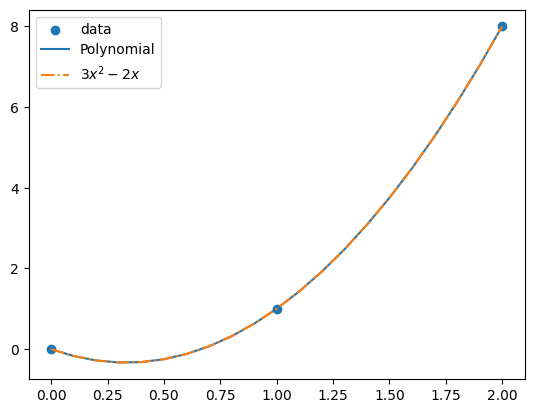

In [ ]:
x_new = np.arange(0, 2.1, 0.1)
plt.scatter(x, y, label='data')
plt.plot(x_new, Polynomial(poly.coef[::-1])(x_new), label='Polynomial')
plt.plot(x_new, 3*x_new**2 - 2*x_new + 0*x_new,
         label=r"$3 x^2 - 2 x$", linestyle='-.')
plt.legend()
plt.show()

In [ ]:
x = [0, 1, 2]
y = [1, 3, 2]

f = lagrange(x, y)

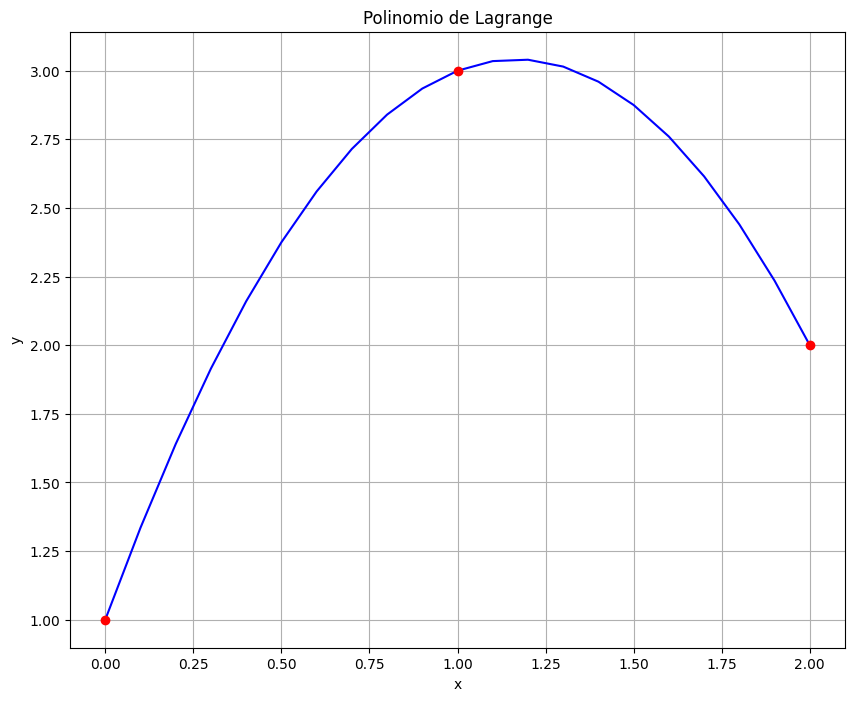

In [ ]:
fig = plt.figure(figsize = (10,8))
plt.plot(x_new, f(x_new), 'b', x, y, 'ro')
plt.title('Polinomio de Lagrange')
plt.grid()
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [ ]:
from scipy.misc import derivative
def f(x):
    return x**3 + x**2

In [ ]:
derivative(f, ,1.0 dx=1e-6)

<ipython-input-46-7ce0b3a04ef8>:1: DeprecationWarning: scipy.misc.derivative is deprecated in SciPy v1.10.0; and will be completely removed in SciPy v1.12.0. You may consider using findiff: https://github.com/maroba/findiff or numdifftools: https://github.com/pbrod/numdifftools
  derivative(f, 1.0, dx=1e-6)


4.999999999921734

## Tarea

**1** Para el problema de la clase pasada encuentre la primera y segunda derivada de forma analítica con sympy y de forma numérica con scipy y grafique ambas.



$$f(x) =e^{\sin(x)}$$

$$\frac{d}{dx} e^{\sin(x)} = cos(x)e^{sin(x)} $$